In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, RocCurveDisplay,  PrecisionRecallDisplay, precision_recall_curve

In [201]:
df = pd.read_csv(r"C:\Users\yogit\OneDrive\Desktop\Data_set\WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [202]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [204]:
df.shape

(7043, 21)

In [205]:
df = df.drop('customerID', axis= 1)

In [206]:

df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [207]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [208]:
df.dtypes


gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [209]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')



In [210]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [211]:
df.duplicated().sum()


22

In [212]:
df.shape

(7043, 20)

In [213]:
df = df.drop_duplicates()

In [214]:
df.shape

(7021, 20)

In [215]:
df[df['TotalCharges'].isna()][['tenure', 'TotalCharges']]


,tenure,TotalCharges
488,0,NaN
753,0,NaN
936,0,NaN
1082,0,NaN
1340,0,NaN
3331,0,NaN
3826,0,NaN
4380,0,NaN
5218,0,NaN
6670,0,NaN


In [216]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7021.000000,7021.000000,7021.000000,7010.000000
mean,0.162512,32.469449,64.851894,2290.353388
std,0.368947,24.534965,30.069001,2266.820832
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.750000,408.312500
50%,0.000000,29.000000,70.400000,1403.875000
75%,0.000000,55.000000,89.900000,3807.837500
max,1.000000,72.000000,118.750000,8684.800000


In [217]:
df['TotalCharges'].isnull().sum()


11

In [218]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [219]:
df.loc[df['tenure'] == 0, 'TotalCharges'] = 0
df[['tenure', 'TotalCharges']].loc[df['tenure'] == 0].head()


,tenure,TotalCharges
488,0,0.0
753,0,0.0
936,0,0.0
1082,0,0.0
1340,0,0.0


In [220]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()


,tenure,MonthlyCharges,TotalCharges
count,7021.000000,7021.000000,7021.000000
mean,32.469449,64.851894,2286.765026
std,24.534965,30.069001,2266.855057
min,0.000000,18.250000,0.000000
25%,9.000000,35.750000,403.350000
50%,29.000000,70.400000,1400.550000
75%,55.000000,89.900000,3801.700000
max,72.000000,118.750000,8684.800000


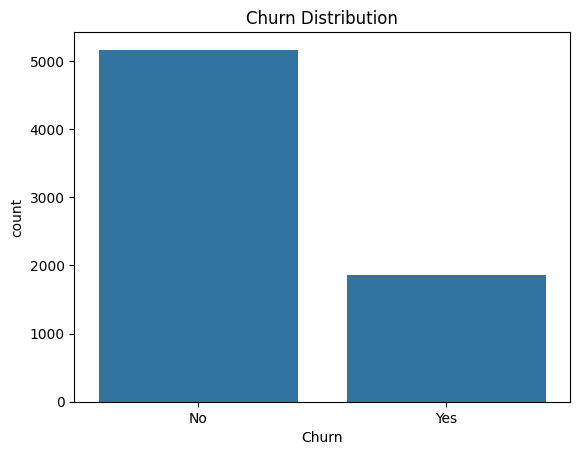

In [221]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

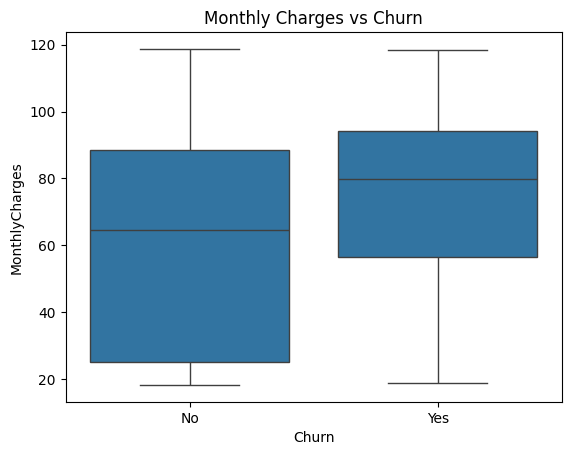

In [222]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


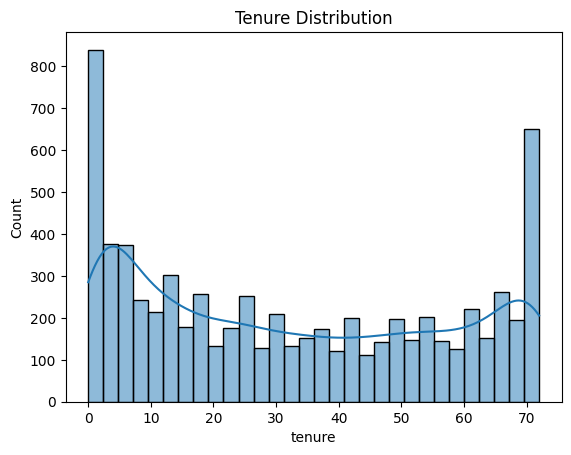

In [223]:
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title('Tenure Distribution')
plt.show()

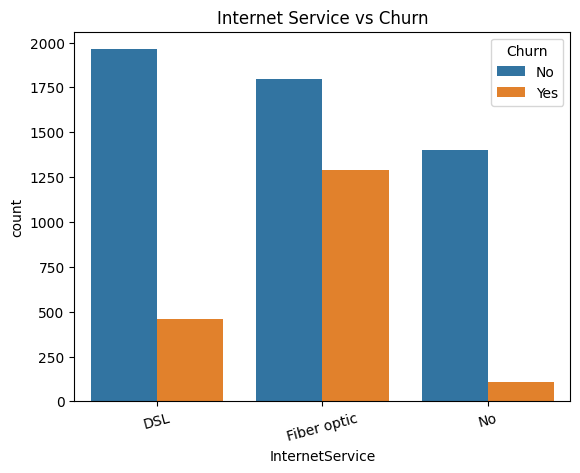

In [224]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Internet Service vs Churn')
plt.xticks(rotation=15)
plt.show()


In [225]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

df_encoded = pd.get_dummies(df, drop_first=True)
#df_encoded['Churn'] = df['Churn']


In [226]:
df_encoded.head()
df_encoded.shape

(7021, 31)

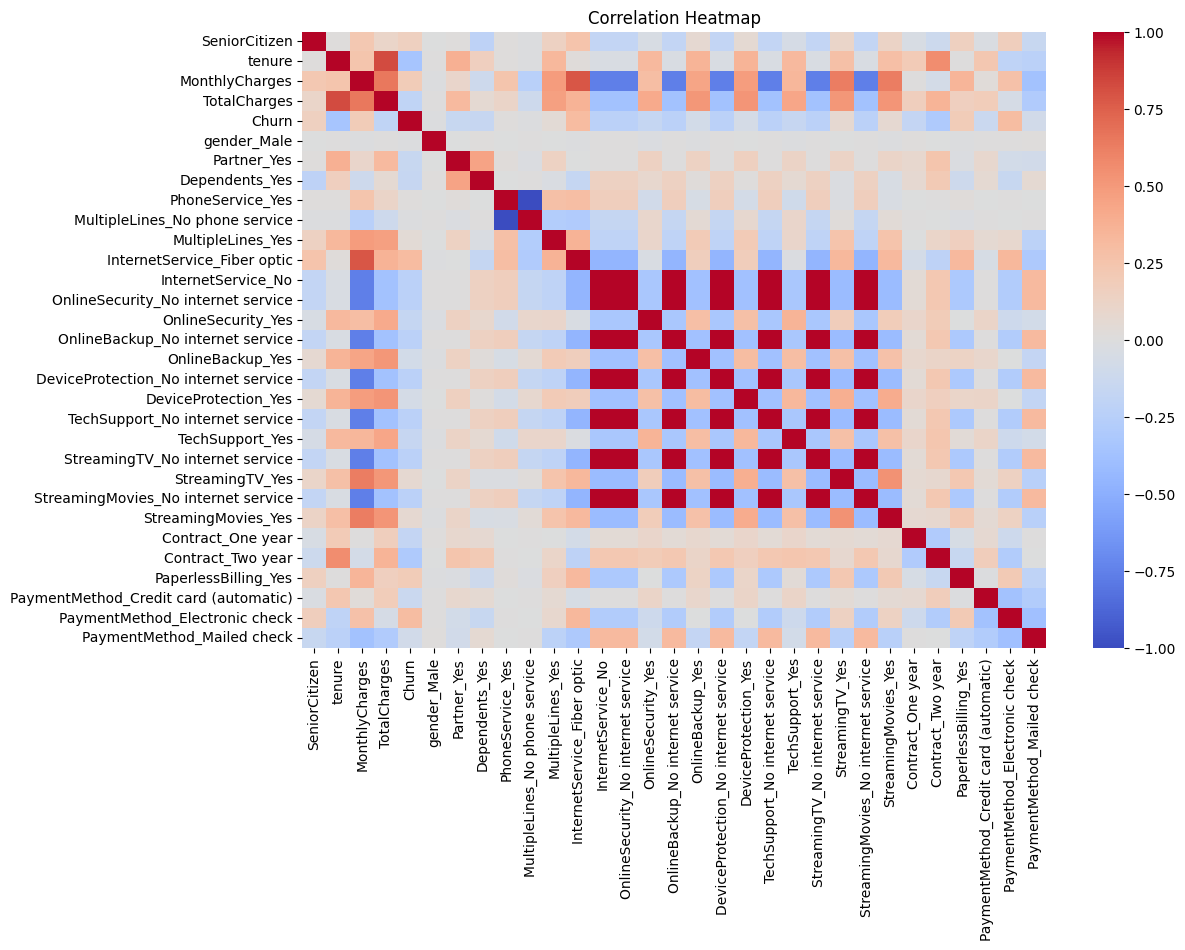

In [227]:
plt.figure(figsize=(12, 8))

corr_matrix = df_encoded.corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [228]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']


In [229]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape


(5616, 30)

In [230]:
X_test.shape

(1405, 30)

In [231]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [232]:
log_model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    solver='lbfgs'
)

log_model.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=3000)

In [233]:
y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

print(confusion_matrix(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

[[750 283]
 [ 82 290]]
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1033
           1       0.51      0.78      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.80      0.74      0.75      1405

Accuracy: 0.7402135231316725
ROC-AUC: 0.8398195567769


In [234]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    log_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print("Cross Validation AUC Scores:")
print(cv_scores)

print("Mean CV AUC:", cv_scores.mean())

Cross Validation AUC Scores:
[0.86587357 0.83450934 0.84201172 0.86152078 0.82579019]
Mean CV AUC: 0.8459411186523681


In [235]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=20,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=20, n_estimators=300, random_state=42)

In [236]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [237]:
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='roc_auc'
)

rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [238]:
best_rf = rf_random.best_estimator_

In [239]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

[[808 225]
 [ 99 273]]
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.73      0.63       372

    accuracy                           0.77      1405
   macro avg       0.72      0.76      0.73      1405
weighted avg       0.80      0.77      0.78      1405

Accuracy: 0.7693950177935943
ROC-AUC: 0.840745974247676


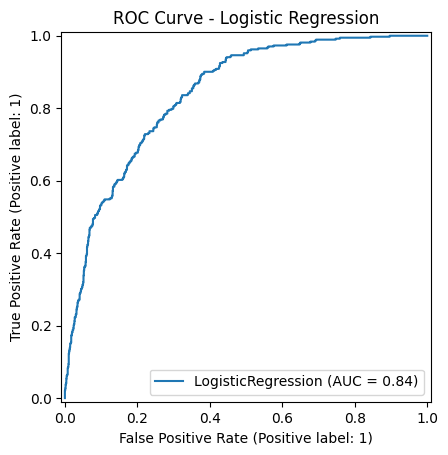

In [240]:
RocCurveDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test
)

plt.title('ROC Curve - Logistic Regression')
plt.show()

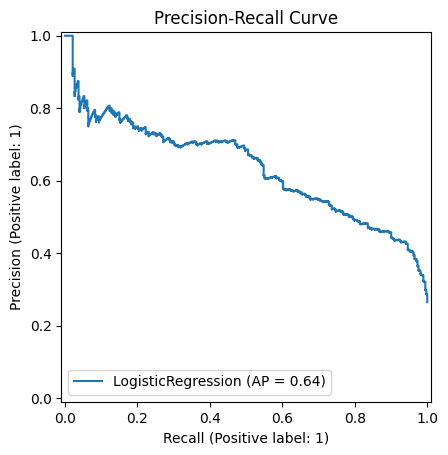

In [241]:
PrecisionRecallDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test
)

plt.title('Precision-Recall Curve')
plt.show()

In [242]:
threshold = 0.50

# Predict using threshold

y_pred_custom = (y_proba_rf >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred_custom))

print(classification_report(y_test, y_pred_custom))

print("Accuracy:", accuracy_score(y_test, y_pred_custom))

[[808 225]
 [ 99 273]]
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.73      0.63       372

    accuracy                           0.77      1405
   macro avg       0.72      0.76      0.73      1405
weighted avg       0.80      0.77      0.78      1405

Accuracy: 0.7693950177935943


In [243]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

tenure                             0.174461
TotalCharges                       0.138454
Contract_Two year                  0.114986
MonthlyCharges                     0.091712
InternetService_Fiber optic        0.083365
PaymentMethod_Electronic check     0.051682
Contract_One year                  0.043069
OnlineSecurity_Yes                 0.033641
TechSupport_Yes                    0.021979
TechSupport_No internet service    0.020012
dtype: float64


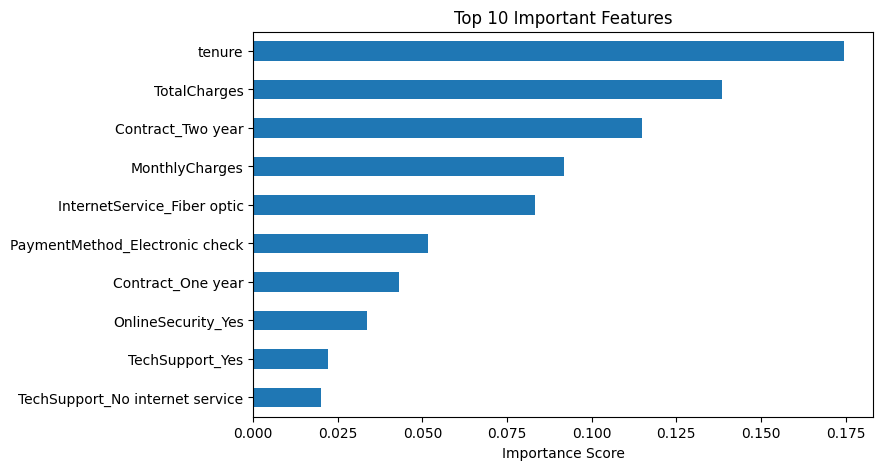

In [244]:
feature_importance.head(10).sort_values().plot(
    kind='barh',
    figsize=(8, 5)
)

plt.title('Top 10 Important Features')
plt.xlabel('Importance Score')
plt.show()

In [245]:
import pickle
import os

In [246]:
os.makedirs("model", exist_ok=True)

# Save model
pickle.dump(
    rf_model,
    open("model/churn_model.pkl", "wb")
)

# Save scaler
pickle.dump(
    scaler,
    open("model/scaler.pkl", "wb")
)

# Save feature order
pickle.dump(
    list(X.columns),
    open("model/feature_order.pkl", "wb")
)

print("Model artifacts saved successfully.")

Model artifacts saved successfully.


In [247]:
pip install shap


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


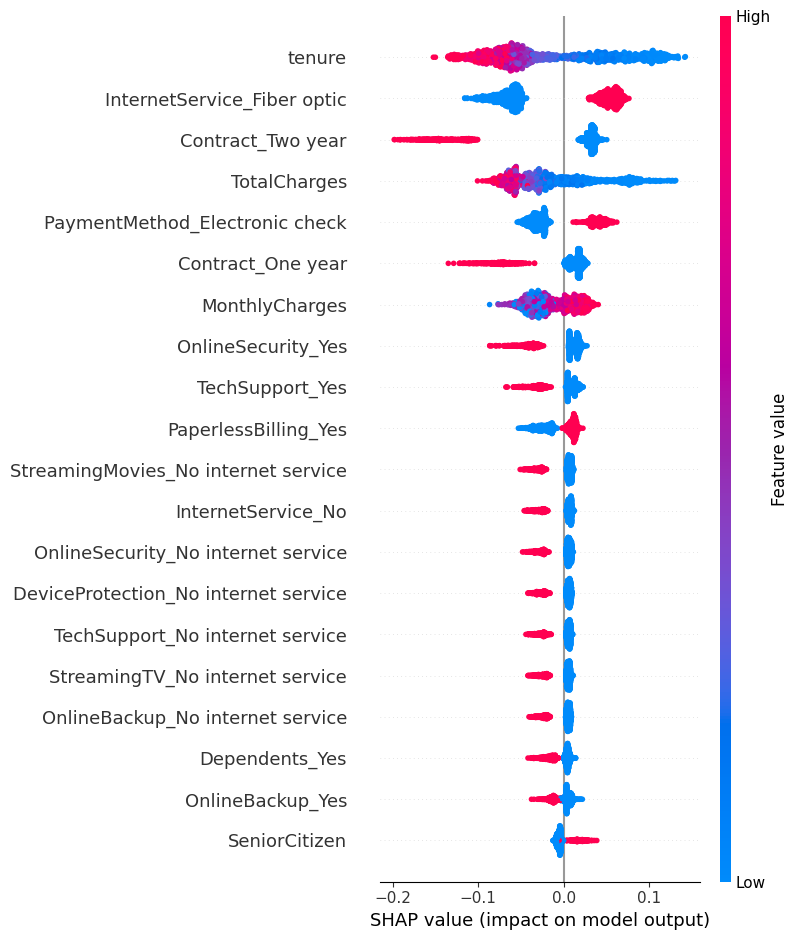

In [250]:
import shap

# Create explainer
explainer = shap.TreeExplainer(best_rf)

# Generate SHAP values
shap_values = explainer.shap_values(X_test)

# For binary classification
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)
